[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeteoSwiss/opendata-nwp-demos/blob/main/10_icon_ch2_pollen_forecast.ipynb)

# Retrieving, Converting, and Visualizing ICON-CH2-EPS Pollen Forecast Data

The numerical weather forecast model ICON can also provide pollen forecasts. All relevant input is considered, such as the distribution of plants, the actual flowering state and the weather. In addition, the most recent observations of MeteoSwiss' real-time pollen observation network are used to fine-tune the pollen forecasts.

At MeteoSwiss, all control runs of ICON-CH2-EPS (initialized at  00, 06, 12 and 18h UTC) calculate pollen concentrations all up to +120 hours ahead. Depending on the season, species include hazel, alder, birch, grass and ambrosia pollen. These forecasts are important information for allergy sufferers to plan their medication and leisure time to minimize exposure. Roughly 20% of the Swiss population is affected.

This notebook demonstrates the full workflow for accessing, converting, and visualizing determinstic ICON-CH2-EPS pollen forecast data. The data is provided by MeteoSwiss as part of Switzerland’s [Open Government Data (OGD) initiative](https://www.meteoswiss.admin.ch/services-and-publications/service/open-data.html).

The ICON model outputs pollen forecasts as specific number concentration — the number of particles per kg of air. This pollen forecast could be used "as is". However, pollen observations are usually provided as volume concentrations (number of particles per volume air). If pollen forecasts should be comparable with observations, the forecasts need to be converted to volume concentrations. This is achieved by simply multiplying the specific number concentrations with the density of the air, which will be demonstrated in this notebook.

For visualization, this notebook uses the [earthkit-plots](https://earthkit-plots.readthedocs.io/en/latest/examples/guide/01-introduction.html) library developed by ECMWF, which offers intuitive plotting tools for meteorological data.

---

## 🔍 **What This Notebook Covers:**

 📥  **Retrieve**  
    Fetch deterministic ICON-CH2-EPS forecast data (pollen and total air density, required for conversion to volume concentration) using [earthkit-data](https://earthkit-data.readthedocs.io/en/latest/) with the [earthkit-data-meteoswiss-opendata](https://meteoswiss.github.io/earthkit-data-meteoswiss-opendata/) source plugin.

 📐  **Convert to volume concentration**  
    Convert specific pollen number concentration to volume concentration.

 🌍  **Visualize**  
    Plot the processed data on a map using [earthkit-plots](https://earthkit-plots.readthedocs.io/en/latest/examples/guide/01-introduction.html), without regridding.

---

⚙️ Notebook & Eccodes Definition Setup

To run the notebook in Google Colab the required dependencies need to be installed. It is skipped in a local Jupyter environment, where dependencies are assumed to be installed already.

Moreover, MeteoSwiss uses custom ecCodes definitions for ICON data. To correctly interpret MeteoSwiss-specific `shortName` values, you must configure the definition path. 

In [1]:
# 📦 Notebook setup
import sys, os, pathlib

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/MeteoSwiss/opendata-nwp-demos.git
    %cd opendata-nwp-demos

    !pip install poetry && poetry config virtualenvs.in-project true && poetry install --no-ansi

    venv = pathlib.Path(".venv")
    site = venv / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
    sys.path.insert(0, str(site))

    # set eccodes definition path
    os.environ["ECCODES_DEFINITION_PATH"] = str((venv / "share/eccodes-cosmo-resources/definitions").resolve())

else:
    import eccodes_cosmo_resources

    # set eccodes definition path
    os.environ["ECCODES_DEFINITION_PATH"] = str(
        eccodes_cosmo_resources.get_definitions_path()
    )

os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

## Retrieving Pollen Forecast
In this first part, we retrieve deterministic ICON-CH2-EPS pollen forecast data.
The earthkit-data-meteoswiss-opendata plugin provides the custom earthkit source that translates a data request into a query to the MeteoSwiss [STAC (SpatioTemporal Asset Catalog) API](https://data.geo.admin.ch/api/stac/static/spec/v1/api.html#tag/STAC/operation/postSearchSTAC) and resolves the matching forecast assets.

## 📥 Retrieve ICON-CH2-EPS Pollen Data

We request the pollen variable `POACsnc`, in addition to the total air density `DEN`  which is needed for conversion to the volume number density.

>⏰ **Forecast Availability**: Forecast data will typically be available a couple of hours after the reference time — due to the model runtime and subsequent upload time. The data remains accessible for 24 hours after upload.

### ⏰ Pollen Data Availability
Pollen data is only available during the pollen season, different for each pollen species. On the first day, pollen are initialized in the KENDA-CH1 08:00 UTC cycle and available in the control of ICON-CH2-EPS starting from the 12:00 UTC run.

| species            | short name    | season window*   | day of year |
| ------------------ | ------------- |----------------- | ----------- |
| alder (alnus)      | ALNUsnc       | Jan 8  - Mar 31  | 8   - 90    |
| ragweed (ambrosia) | AMBRsnc       | Jul 9  - Sep 30  | 190 - 273   |
| birch (betula)     | BETUsnc       | Mar 18 - May 25  | 77  - 145   |
| hazel (corylus)    | CORYsnc       | Jan 8  - Mar 17  | 8   - 76    |
| grasses (poaceae)  | POACsnc       | Apr 1  - Aug 31  | 91  - 243   |

\* for non-leap years; ground truth is the day of year


In [2]:
param_list = ['DEN', 'POACsnc']
reqlist = []

for param in param_list:
    req = {
        "collection": "ogd-forecasting-icon-ch2",
        "variable": param,
        "ref_time": "latest",
        "perturbed": False,
        "lead_time": "P0DT6H"
    }
    reqlist.append((param, req))

> 💡 **Tip**: Use temporary caching with earthkit-data to skip repeated downloads — it's auto-cleaned after the session.
> *For more details, see the [earthkit-data caching docs](https://earthkit-data.readthedocs.io/en/latest/examples/cache.html)*.

> 💡 **Hint**: If you get an error message containing `HTTPError: 403 Client Error: Forbidden for url`, you may be trying to retrieve data older than 24h hours, or the requested pollen variable is currently unavailable (not in pollen season). Please adjust your requests.

In [3]:
import earthkit.data as ekd
ekd.config.set("cache-policy", "temporary")

data_dict = {}
for param, request in reqlist:

    forecast = ekd.from_source(
        "meteoswiss-opendata",
        **request,
        )

    data_dict[param] = forecast.to_xarray(
        time_dims=["forecast_reference_time", "step"],
        squeeze=False
        )

## 📐 Convert to volume concentration

The volume number concentration is obtained by multiplying the specific number concentration by the total air density $\rho$.

> ⚠️ **Location of pollen variables**: On the grid, the provided pollen variables and density DEN are associated with the lowest full level, i.e., represent the mean value over the first 20m above ground.

In [4]:
data_dict['POACsnc'].POACsnc.units

'1 / kilogram'

In [5]:
data_dict['POACsnc'].POACsnc.units

'1 / kilogram'

In [6]:
data_dict['DEN'].DEN.units

'kilogram / meter ** 3'

In [7]:
poac_concentration = data_dict['POACsnc'].POACsnc * data_dict['DEN'].DEN  # units m^(-3)

## 🗺️ Visualize the data

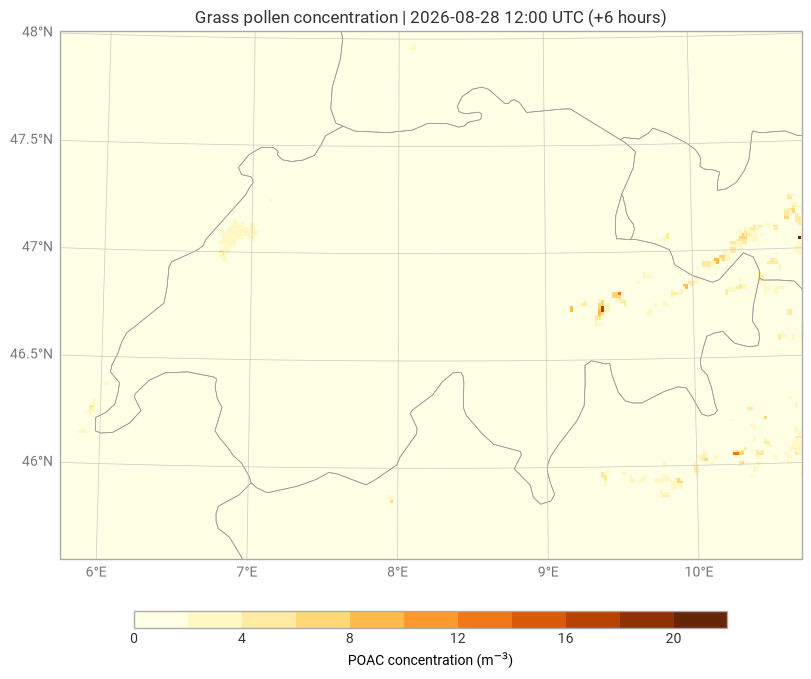

In [9]:
import pandas as pd
import earthkit.plots as ekp
from earthkit.plots.styles import Style


# === Create Map ===
chart = ekp.Map(domain="Switzerland")

chart.grid_cells(poac_concentration, x="longitude", y="latitude", style=Style(colors="YlOrBr", legend_style="colorbar"))


# === Add Map Features ===
chart.land()
chart.coastlines()
chart.borders()
chart.gridlines()


# === Annotate Chart ===
ref_time = pd.to_datetime(poac_concentration.forecast_reference_time.values[0]).strftime("%Y-%m-%d %H:%M UTC")
lead_time = poac_concentration.step.values.astype('timedelta64[h]')

title = f"Grass pollen concentration | {ref_time} (+{lead_time[0]})"
legend_label = "POAC concentration (m$^{{-3}}$)"

chart.title(title)
chart.legend(label=legend_label)


# === Show Plot ===
chart.show()
